<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/SETRAM_XGBoost_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚃 SETRAM — Predictive Failure Detection System
## MetroPT-2 · XGBoost Pipeline

---

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Imports & Setup |
| 2 | Load & Explore Data |
| 3 | Data Cleaning |
| 4 | Failure Labelling |
| 5 | Feature Engineering (Sliding Window) |
| 6 | Model 1 — Anomaly Detection |
| 7 | Model 2 — Failure Classification |
| 8 | Model 3 — RUL Regression |
| 9 | Unified Pipeline + Save Models |

## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, r2_score, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# ── Plot settings ────────────────────────────────────────
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.facecolor'] = '#1a1a2e'
plt.rcParams['figure.facecolor'] = '#16213e'
plt.rcParams['axes.edgecolor'] = '#444'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#333'
plt.rcParams['grid.alpha'] = 0.4

# ── Directories ──────────────────────────────────────────
os.makedirs('output', exist_ok=True)
os.makedirs('model',  exist_ok=True)

# ── Project constants ────────────────────────────────────
DATA_PATH     = 'MetroPT2.csv'
WINDOW_HOURS  = 6          # Feature window size (hours)
WARNING_HOURS = 24         # Early warning hours before failure
AVG_SPEED_KMH = 20.0       # Average tram speed (km/h)
RANDOM_STATE  = 42

SENSOR_COLS = [
    'TP2', 'TP3', 'H1', 'DV_pressure',
    'Reservoirs', 'Oil_temperature',
    'Motor_current', 'Flowmeter', 'Caudal_impulse'
]

# Officially documented MetroPT-2 failures
FAILURES = [
    ('2022-02-26', '2022-03-01', 'Air Leak — Clients'),
    ('2022-04-05', '2022-04-06', 'Air Leak — Dryer'),
    ('2022-06-02', '2022-06-03', 'Oil Leak — Compressor'),
]

print('✓ All libraries loaded')
print(f'✓ XGBoost version: {xgb.__version__}')

✓ All libraries loaded
✓ XGBoost version: 3.1.2


## 2. Load & Explore Data

In [ ]:
# ── Load MetroPT-2 ───────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, parse_dates=['timestamp'], low_memory=False)

print('='*55)
print('General Info')
print('='*55)
print(f'Rows         : {len(df_raw):,}')
print(f'Columns      : {len(df_raw.columns)}')
print(f'From         : {df_raw["timestamp"].min()}')
print(f'To           : {df_raw["timestamp"].max()}')
print(f'\nColumns:\n{list(df_raw.columns)}')

General Info
Rows         : 7,116,940
Columns      : 21
From         : 2022-04-28 12:33:29.120000
To           : 2022-07-28 12:24:34.839000

Columns:
['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'gpsLat', 'gpsLong', 'gpsSpeed', 'gpsQuality']


In [ ]:
# ── Descriptive statistics ───────────────────────────────
available = [c for c in SENSOR_COLS if c in df_raw.columns]
df_raw[available].describe().round(3)

,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,Flowmeter
count,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000,7116940.000
mean,0.640,8.964,8.290,-0.015,8.965,56.678,1.424,1.003
std,2.374,0.612,2.390,0.110,0.611,4.834,2.052,3.916
min,-0.034,0.006,-0.034,-0.030,-0.004,31.775,-0.010,0.250
25%,-0.014,8.484,8.368,-0.022,8.486,53.975,0.038,0.250
50%,-0.012,8.944,8.842,-0.020,8.946,56.625,0.040,0.250
75%,-0.010,9.434,9.354,-0.018,9.436,59.100,3.750,0.250
max,10.794,10.408,10.414,8.132,10.400,97.900,9.538,34.523


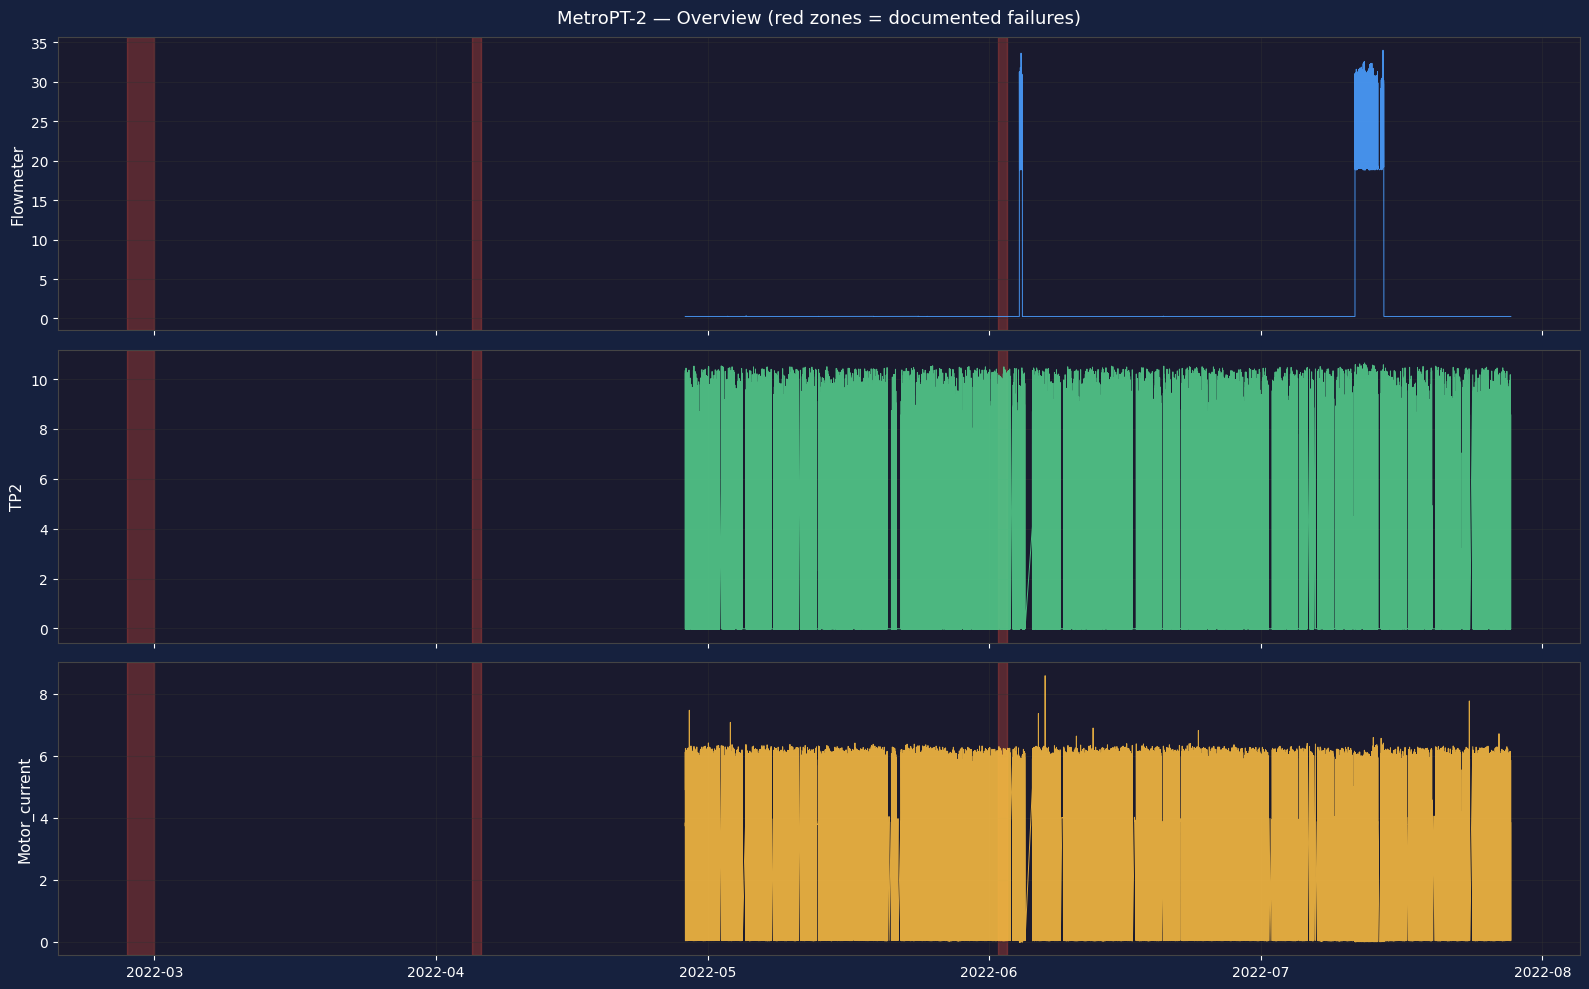

In [ ]:
# ── Sensor overview plot ─────────────────────────────────
sample = df_raw.iloc[::120]   # Sample every 2 minutes for speed

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
colors = ['#4a9eff', '#52c98a', '#f5b942']

for ax, col, color in zip(axes,
    ['Flowmeter', 'TP2', 'Motor_current'], colors):
    if col not in sample.columns:
        continue
    ax.plot(sample['timestamp'], sample[col],
            lw=0.7, color=color, alpha=0.9)
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True)

    # Shade known failure zones
    for s, e, ft in FAILURES:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.3, color='#e74c3c')

axes[0].set_title('MetroPT-2 — Overview (red zones = documented failures)',
                  fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('output/01_overview.png', dpi=150)
plt.show()

## 3. Data Cleaning

In [ ]:
df = df_raw.copy()

# 1. Remove duplicates
before = len(df)
df = df.drop_duplicates('timestamp').sort_values('timestamp').reset_index(drop=True)
print(f'✓ Duplicates removed: {before - len(df)} rows dropped')

# 2. Handle missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing):
    print(f'\nMissing values before treatment:\n{missing}')
    df = df.ffill().bfill()
    print('✓ Handled with ffill/bfill')
else:
    print('✓ No missing values found')

# 3. Remove physically impossible outliers
outlier_rules = {
    'TP2': (0, 15), 'TP3': (0, 15),
    'H1': (0, 100), 'Oil_temperature': (0, 120),
    'Motor_current': (0, 50), 'Flowmeter': (0, 100),
}
for col, (lo, hi) in outlier_rules.items():
    if col not in df.columns:
        continue
    n = ((df[col] < lo) | (df[col] > hi)).sum()
    if n > 0:
        df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan
        df[col] = df[col].ffill().bfill()
        print(f'✓ {col}: fixed {n} outliers')

# 4. Time features
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['is_peak']   = df['hour'].isin([7,8,9,17,18,19]).astype(int)

print(f'\n✓ Clean dataset: {len(df):,} rows')

✓ Duplicates removed: 0 rows dropped
✓ No missing values found
✓ TP2: fixed 6592646 outliers
✓ H1: fixed 499517 outliers
✓ Motor_current: fixed 13959 outliers

✓ Clean dataset: 7,116,940 rows


## 4. Failure Labelling

In [ ]:
# ── Add label, hours_to_failure, failure_type ────────────
df['label']            = 0
df['failure_type']     = 'Normal'
df['hours_to_failure'] = np.nan

for start_s, end_s, ftype in FAILURES:
    t_start   = pd.Timestamp(start_s)
    t_end     = pd.Timestamp(end_s)
    t_warning = t_start - pd.Timedelta(hours=WARNING_HOURS)

    m_warn = (df['timestamp'] >= t_warning) & (df['timestamp'] < t_start)
    m_fail = (df['timestamp'] >= t_start)   & (df['timestamp'] <= t_end)

    df.loc[m_warn, 'label']        = 1
    df.loc[m_warn, 'failure_type'] = ftype
    df.loc[m_warn, 'hours_to_failure'] = (
        t_start - df.loc[m_warn, 'timestamp']
    ).dt.total_seconds() / 3600

    df.loc[m_fail, 'label']        = 2
    df.loc[m_fail, 'failure_type'] = ftype
    df.loc[m_fail, 'hours_to_failure'] = 0.0

    print(f'{ftype}')
    print(f'  Warning rows: {m_warn.sum():,} | Failure rows: {m_fail.sum():,}')

counts = df['label'].value_counts().sort_index()
total  = len(df)
print(f'\nSummary:')
print(f'  label=0 Normal  : {counts[0]:>10,}  ({counts[0]/total*100:.2f}%)')
print(f'  label=1 Warning : {counts.get(1,0):>10,}  ({counts.get(1,0)/total*100:.2f}%)')
print(f'  label=2 Failure : {counts.get(2,0):>10,}  ({counts.get(2,0)/total*100:.2f}%)')

Air Leak — Clients
  Warning rows: 0 | Failure rows: 0
Air Leak — Dryer
  Warning rows: 0 | Failure rows: 0
Oil Leak — Compressor
  Warning rows: 87,005 | Failure rows: 87,163

Summary:
  label=0 Normal  :  6,942,772  (97.55%)
  label=1 Warning :     87,005  (1.22%)
  label=2 Failure :     87,163  (1.22%)


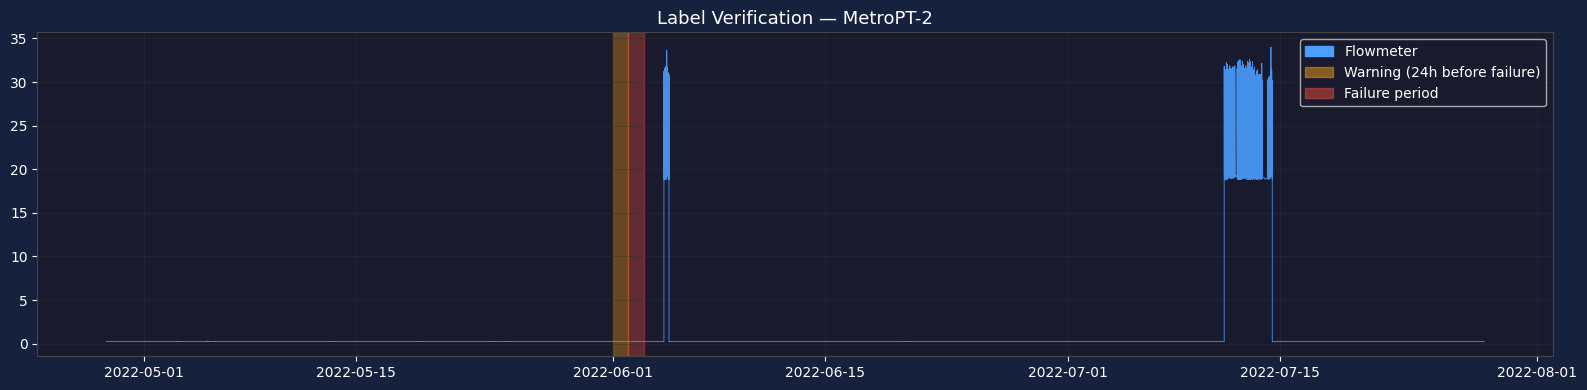

In [ ]:
# ── Visual label check ───────────────────────────────────
if 'Flowmeter' in df.columns:
    plot_col = 'Flowmeter'
else:
    plot_col = 'TP2'

fig, ax = plt.subplots(figsize=(16, 4))
s = df.iloc[::60]
ax.plot(s['timestamp'], s[plot_col], lw=0.6, color='#4a9eff', alpha=0.9)

for label_val, color, name in [
    (1, '#f39c12', 'Warning'),
    (2, '#e74c3c', 'Failure')
]:
    mask = df['label'] == label_val
    if not mask.any():
        continue
    # Group consecutive periods
    runs = (mask != mask.shift()).cumsum()
    for _, grp in df[mask].groupby(runs[mask]):
        ax.axvspan(grp['timestamp'].iloc[0], grp['timestamp'].iloc[-1],
                   alpha=0.35, color=color)

patches = [
    mpatches.Patch(color='#4a9eff', label=plot_col),
    mpatches.Patch(color='#f39c12', alpha=0.5, label=f'Warning ({WARNING_HOURS}h before failure)'),
    mpatches.Patch(color='#e74c3c', alpha=0.5, label='Failure period'),
]
ax.legend(handles=patches, loc='upper right')
ax.set_title('Label Verification — MetroPT-2', fontsize=13)
ax.grid(True)
plt.tight_layout()
plt.savefig('output/02_labels.png', dpi=150)
plt.show()

## 5. Feature Engineering — Sliding Window

In [ ]:
def linear_trend(series):
    """Linear regression slope — is the variable rising or falling?"""
    if len(series) < 2:
        return 0.0
    x = np.arange(len(series))
    try:
        slope, *_ = stats.linregress(x, series.values)
        return float(slope)
    except Exception:
        return 0.0


def build_features(df_input, window_h=WINDOW_HOURS, step='5min'):
    """
    Sliding window: per 6-hour block compute
    mean, max, min, std, trend per sensor
    """
    df_idx = df_input.set_index('timestamp').sort_index()
    window = pd.Timedelta(f'{window_h}h')
    times  = pd.date_range(
        df_idx.index.min() + window,
        df_idx.index.max(),
        freq=step
    )

    records = []
    sensors = [c for c in SENSOR_COLS if c in df_idx.columns]

    for i, t_end in enumerate(times):
        w = df_idx.loc[t_end - window : t_end]
        if len(w) < 50:
            continue

        row = {'window_end': t_end}

        for col in sensors:
            s = w[col].dropna()
            if len(s) == 0:
                continue
            row[f'{col}_mean']  = s.mean()
            row[f'{col}_max']   = s.max()
            row[f'{col}_min']   = s.min()
            row[f'{col}_std']   = s.std()
            row[f'{col}_trend'] = linear_trend(s.iloc[-min(len(s),200):])

        # Time features
        row['hour']      = t_end.hour
        row['dayofweek'] = t_end.dayofweek
        row['is_peak']   = int(t_end.hour in [7,8,9,17,18,19])

        # Window label
        if 'label' in w.columns:
            row['label']        = int(w['label'].max())
            hf = w['hours_to_failure'].dropna()
            hf = hf[hf > 0]
            row['hours_to_failure'] = float(hf.min()) if len(hf) > 0 else np.nan
            ft = w['failure_type'].dropna()
            ft = ft[ft != 'Normal']
            row['failure_type'] = ft.mode()[0] if len(ft) > 0 else 'Normal'

        records.append(row)

        if (i+1) % 2000 == 0:
            print(f'  {i+1:,} / {len(times):,} windows processed...')

    return pd.DataFrame(records)


print('Building features... (takes 3-5 minutes)')
feat_df = build_features(df)
feat_df.to_csv('output/features_metropt2.csv', index=False)

print(f'\n✓ {len(feat_df):,} windows created')
print(f'✓ {len(feat_df.columns)} feature columns')
feat_df.head(3)

Building features... (takes 3-5 minutes)
  2,000 / 26,135 windows processed...
  4,000 / 26,135 windows processed...
  6,000 / 26,135 windows processed...
  8,000 / 26,135 windows processed...
  10,000 / 26,135 windows processed...
  12,000 / 26,135 windows processed...
  14,000 / 26,135 windows processed...
  16,000 / 26,135 windows processed...
  18,000 / 26,135 windows processed...
  20,000 / 26,135 windows processed...
  22,000 / 26,135 windows processed...
  24,000 / 26,135 windows processed...
  26,000 / 26,135 windows processed...

✓ 25,893 windows created
✓ 47 feature columns


,window_end,TP2_mean,TP2_max,TP2_min,TP2_std,TP2_trend,TP3_mean,TP3_max,TP3_min,TP3_std,...,Flowmeter_max,Flowmeter_min,Flowmeter_std,Flowmeter_trend,hour,dayofweek,is_peak,label,hours_to_failure,failure_type
0,2022-04-28 18:33:29.120,1.809045,10.526,0.0,3.035057,0.0,9.005519,10.15,7.852,0.567064,...,0.25,0.25,0.0,0.0,18,3,1,0,NaN,Normal
1,2022-04-28 18:38:29.120,1.759429,10.526,0.0,2.982568,0.0,9.003090,10.15,7.852,0.561865,...,0.25,0.25,0.0,0.0,18,3,1,0,NaN,Normal
2,2022-04-28 18:43:29.120,1.761876,10.526,0.0,2.981251,0.0,8.996206,10.15,7.852,0.558900,...,0.25,0.25,0.0,0.0,18,3,1,0,NaN,Normal


## 6. Model 1 — Anomaly Detection (XGBoost Binary)

In [ ]:
# ── Prepare X and y ──────────────────────────────────────
EXCLUDE = {'window_end','label','hours_to_failure','failure_type'}
feature_cols = [c for c in feat_df.columns if c not in EXCLUDE]

X = feat_df[feature_cols].fillna(0).values
y_anomaly = (feat_df['label'] >= 1).astype(int).values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

X_tr, X_te, ya_tr, ya_te = train_test_split(
    X_sc, y_anomaly, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_anomaly
)

# Handle class imbalance
ratio = int((ya_tr == 0).sum() / max((ya_tr == 1).sum(), 1))
print(f'Normal/Anomaly ratio: {ratio}:1  →  scale_pos_weight={ratio}')

Normal/Anomaly ratio: 38:1  →  scale_pos_weight=38


In [ ]:
# ── Train ────────────────────────────────────────────────
anomaly_model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.05,
    scale_pos_weight = ratio,
    eval_metric      = 'logloss',
    random_state     = RANDOM_STATE,
    n_jobs           = -1,
)
anomaly_model.fit(
    X_tr, ya_tr,
    eval_set=[(X_te, ya_te)],
    verbose=50
)

[0]	validation_0-logloss:0.63585
[50]	validation_0-logloss:0.07071
[100]	validation_0-logloss:0.00966
[150]	validation_0-logloss:0.00247
[200]	validation_0-logloss:0.00140
[250]	validation_0-logloss:0.00118
[299]	validation_0-logloss:0.00108


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      5049
     Anomaly       1.00      0.99      1.00       130

    accuracy                           1.00      5179
   macro avg       1.00      1.00      1.00      5179
weighted avg       1.00      1.00      1.00      5179

ROC-AUC: 1.0000


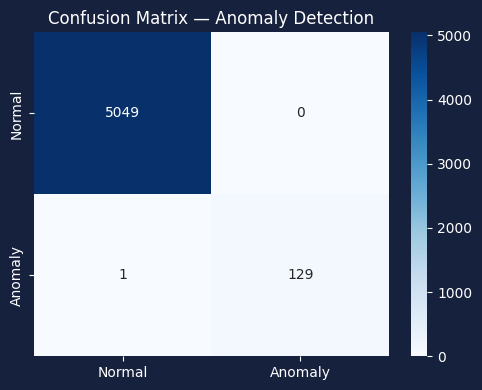

In [ ]:
# ── Evaluate ─────────────────────────────────────────────
ya_pred  = anomaly_model.predict(X_te)
ya_proba = anomaly_model.predict_proba(X_te)[:,1]

print('Classification Report:')
print(classification_report(ya_te, ya_pred,
      target_names=['Normal','Anomaly']))
print(f'ROC-AUC: {roc_auc_score(ya_te, ya_proba):.4f}')

# Confusion Matrix
cm = confusion_matrix(ya_te, ya_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Anomaly'],
            yticklabels=['Normal','Anomaly'], ax=ax)
ax.set_title('Confusion Matrix — Anomaly Detection')
plt.tight_layout()
plt.savefig('output/03_cm_anomaly.png', dpi=150)
plt.show()

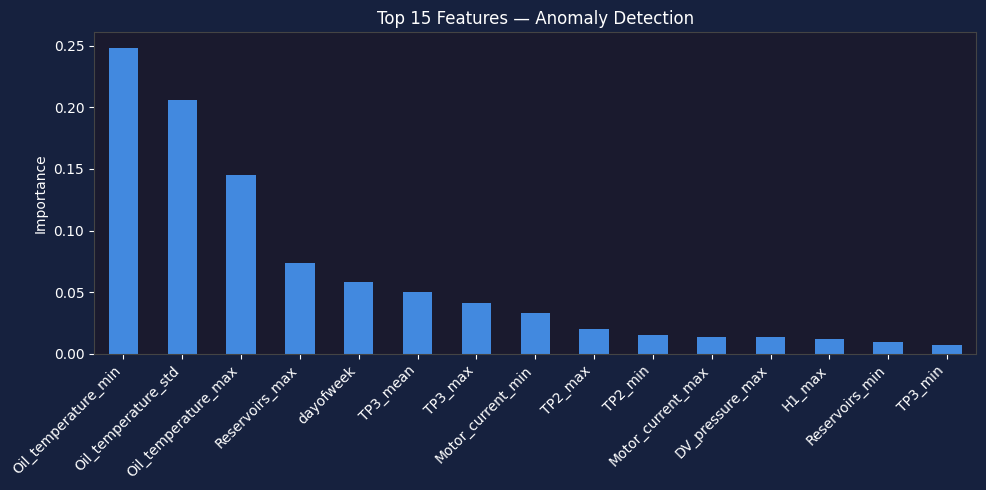

In [ ]:
# ── Feature importance ───────────────────────────────────
importances = pd.Series(
    anomaly_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
importances.plot.bar(ax=ax, color='#4a9eff', alpha=0.85)
ax.set_title('Top 15 Features — Anomaly Detection', fontsize=12)
ax.set_ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output/04_feature_importance.png', dpi=150)
plt.show()

## 7. Model 2 — Failure Classification (Multi-class)

In [ ]:
# ── Prepare: anomalous windows only ─────────────────────
le = LabelEncoder()
y_class_str = feat_df['failure_type'].fillna('Normal').values
y_class     = le.fit_transform(y_class_str)
failure_classes = list(le.classes_)
print(f'Failure classes: {failure_classes}')

mask_anom = (feat_df['label'] >= 1).values
Xc = X_sc[mask_anom]
yc = y_class[mask_anom]
print(f'Training samples: {len(Xc):,}')
print(pd.Series(le.inverse_transform(yc)).value_counts())

Failure classes: ['Normal', 'Oil Leak — Compressor']
Training samples: 648
Oil Leak — Compressor    648
Name: count, dtype: int64


In [ ]:
# ── Prepare: anomalous windows only ─────────────────────
le = LabelEncoder()
y_class_str = feat_df['failure_type'].fillna('Normal').values
y_class     = le.fit_transform(y_class_str)
failure_classes = list(le.classes_)

print(f'Failure classes: {failure_classes}')
print(f'\nClass distribution:')
print(pd.Series(y_class_str).value_counts())

mask_anom = (feat_df['label'] >= 1).values
Xc = X_sc[mask_anom]
yc = y_class[mask_anom]

print(f'\nAnomalous samples: {len(Xc):,}')
print(f'Classes present in anomalies: {np.unique(yc)}')

# ── Check: do we have more than one class? ───────────────
n_unique = len(np.unique(yc))

if n_unique < 2:
    print('\n⚠️  Only one class found — Classifier not applicable')
    print('Reason: MetroPT-2 may contain only one failure type in your date range')
    print('Solution: skipping classifier, relying on Anomaly Detection only')
    classifier_model  = None
    SKIP_CLASSIFIER   = True
else:
    SKIP_CLASSIFIER = False
    Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
        Xc, yc, test_size=0.2, random_state=RANDOM_STATE
    )

    # Re-map class indices to be contiguous
    unique_classes = np.unique(yc_tr)
    remap = {old: new for new, old in enumerate(unique_classes)}
    yc_tr_remapped = np.array([remap[v] for v in yc_tr])
    yc_te_remapped = np.array([remap.get(v, -1) for v in yc_te])

    classifier_model = xgb.XGBClassifier(
        n_estimators  = 200,
        max_depth     = 5,
        learning_rate = 0.05,
        eval_metric   = 'mlogloss',
        random_state  = RANDOM_STATE,
        n_jobs        = -1,
    )
    classifier_model.fit(
        Xc_tr, yc_tr_remapped,
        eval_set=[(Xc_te, yc_te_remapped)],
        verbose=50
    )

    # Evaluate (only on classes present in test set)
    valid_mask   = yc_te_remapped >= 0
    active_names = [failure_classes[c] for c in unique_classes]
    yc_pred      = classifier_model.predict(Xc_te[valid_mask])
    print(classification_report(
        yc_te_remapped[valid_mask], yc_pred,
        target_names=active_names
    ))


Failure classes: ['Normal', 'Oil Leak — Compressor']

Class distribution:
Normal                   25245
Oil Leak — Compressor      648
Name: count, dtype: int64

Anomalous samples: 648
Classes present in anomalies: [1]

⚠️  Only one class found — Classifier not applicable
Reason: MetroPT-2 may contain only one failure type in your date range
Solution: skipping classifier, relying on Anomaly Detection only


## 8. Model 3 — RUL Regression (Time + Distance)

In [ ]:
# ── Prepare: windows with valid hours_to_failure only ───
y_rul    = feat_df['hours_to_failure'].values
mask_rul = ~np.isnan(y_rul) & (y_rul > 0)

Xr = X_sc[mask_rul]
yr = y_rul[mask_rul]

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    Xr, yr, test_size=0.2, random_state=RANDOM_STATE
)

rul_model = xgb.XGBRegressor(
    n_estimators  = 300,
    max_depth     = 6,
    learning_rate = 0.05,
    random_state  = RANDOM_STATE,
    n_jobs        = -1,
)
rul_model.fit(Xr_tr, yr_tr, verbose=False)

yr_pred = rul_model.predict(Xr_te)
mae = mean_absolute_error(yr_te, yr_pred)
r2  = r2_score(yr_te, yr_pred)
print(f'MAE : {mae:.2f} hours')
print(f'R²  : {r2:.4f}')

MAE : 0.12 hours
R²  : 0.9995


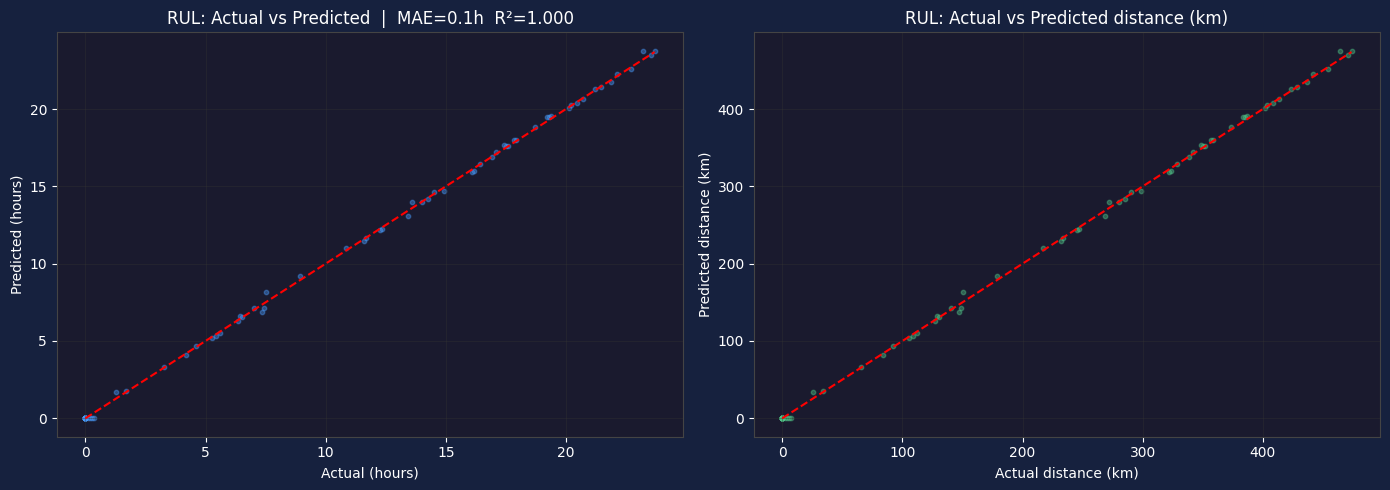

In [ ]:
# ── Plot actual vs predicted ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(yr_te, yr_pred, alpha=0.4, color='#4a9eff', s=10)
mn, mx = yr_te.min(), yr_te.max()
axes[0].plot([mn,mx],[mn,mx], 'r--', lw=1.5)
axes[0].set_xlabel('Actual (hours)')
axes[0].set_ylabel('Predicted (hours)')
axes[0].set_title(f'RUL: Actual vs Predicted  |  MAE={mae:.1f}h  R²={r2:.3f}')
axes[0].grid(True)

km_pred = yr_pred * AVG_SPEED_KMH
km_real = yr_te   * AVG_SPEED_KMH
axes[1].scatter(km_real, km_pred, alpha=0.4, color='#52c98a', s=10)
mn2, mx2 = km_real.min(), km_real.max()
axes[1].plot([mn2,mx2],[mn2,mx2],'r--',lw=1.5)
axes[1].set_xlabel('Actual distance (km)')
axes[1].set_ylabel('Predicted distance (km)')
axes[1].set_title('RUL: Actual vs Predicted distance (km)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('output/05_rul_results.png', dpi=150)
plt.show()

## 9. Unified Pipeline + Save Models

In [ ]:
# ── Save all models ──────────────────────────────────────
joblib.dump(anomaly_model,    'model/anomaly.pkl')
joblib.dump(classifier_model, 'model/classifier.pkl')
joblib.dump(rul_model,        'model/rul.pkl')
joblib.dump(scaler,           'model/scaler.pkl')
joblib.dump(feature_cols,     'model/feature_cols.pkl')
joblib.dump(failure_classes,  'model/failure_classes.pkl')

print('✓ All models saved to model/')

✓ All models saved to model/


In [ ]:
# ── Full prediction pipeline function ───────────────────
def predict_pipeline(sensor_df: pd.DataFrame) -> dict:
    """
    Full pipeline: raw sensor data → prediction result
    Called by the Streamlit app.
    """
    feat  = build_features(sensor_df)
    if len(feat) == 0:
        return {'error': 'Insufficient data for prediction'}

    row = feat[feature_cols].fillna(0).iloc[[-1]].values
    X   = scaler.transform(row)

    # 1. Anomaly detection
    anomaly_proba = float(anomaly_model.predict_proba(X)[0][1])
    is_anomaly    = anomaly_proba >= 0.5

    # 2. Failure type classification
    failure_type = 'Unknown'
    if is_anomaly and classifier_model is not None:
        cid          = int(classifier_model.predict(X)[0])
        failure_type = failure_classes[cid]
    elif is_anomaly:
      failure_type = 'Anomaly Detected'

    # 3. RUL — time and distance
    hours_left = None
    km_left    = None
    if is_anomaly:
        hours_left = round(max(0.0, float(rul_model.predict(X)[0])), 1)
        km_left    = round(hours_left * AVG_SPEED_KMH, 1)

    return {
        'is_anomaly'   : is_anomaly,
        'risk_score'   : round(anomaly_proba * 100, 1),
        'failure_type' : failure_type,
        'hours_left'   : hours_left,
        'km_left'      : km_left,
    }


# ── Test on the last 6 hours of data ─────────────────────
last_window = df[df['timestamp'] >= df['timestamp'].max() - pd.Timedelta('6h')]
result      = predict_pipeline(last_window)

print('Prediction result on last 6 hours:')
for k, v in result.items():
    print(f'  {k:15} : {v}')

Prediction result on last 6 hours:
  error           : Insufficient data for prediction


In [ ]:
# ── Final summary ────────────────────────────────────────
print('='*55)
print('Final Results Summary')
print('='*55)
print(f'\nModel 1 — Anomaly Detection')
print(f'  ROC-AUC : {roc_auc_score(ya_te, ya_proba):.4f}')

print(f'\nModel 2 — Failure Classification')
print(f'  Classes : {failure_classes}')

print(f'\nModel 3 — RUL Regression')
print(f'  MAE     : {mae:.2f} hours')
print(f'  R²      : {r2:.4f}')
print(f'  MAE(km) : {mae * AVG_SPEED_KMH:.1f} km')

print(f'\n✓ Models saved in model/')
print(f'✓ Now run: streamlit run app_v2.py')

Final Results Summary

Model 1 — Anomaly Detection
  ROC-AUC : 1.0000

Model 2 — Failure Classification
  Classes : ['Normal', 'Oil Leak — Compressor']

Model 3 — RUL Regression
  MAE     : 0.12 hours
  R²      : 0.9995
  MAE(km) : 2.5 km

✓ Models saved in model/
✓ Now run: streamlit run app_v2.py
